# Regressão Linear Simples
## Previsão de Limite de Crédito Bancário

Neste notebook, construiremos um modelo de regressão linear simples para prever o **limite de crédito** que um banco aprova para seus clientes com base na **renda mensal**.

O modelo segue a equação: **y = ax + b**, onde:
- **y** → limite de crédito aprovado
- **x** → renda mensal do cliente
- **a** → coeficiente angular (inclinação da reta)
- **b** → intercepto (valor base)

## 1. Importação das Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')

## 2. Carregamento dos Dados

O dataset contém registros de 150 clientes de um banco, com sua renda mensal e o limite de crédito aprovado.

In [2]:
df = pd.read_csv('dados_limite_credito.csv')
print(f'Dimensões: {df.shape[0]} linhas × {df.shape[1]} colunas')
df.head(10)

Dimensões: 150 linhas × 2 colunas


,renda_mensal,limite_credito
0,10614.42,25528.45
1,23866.43,56995.88
2,18835.86,44753.06
3,15769.15,35431.68
4,5588.43,16639.03
5,5587.87,15855.98
6,3335.92,10754.69
7,21922.05,50101.94
8,15825.65,40704.57
9,18285.67,40753.34


In [3]:
df.describe()

,renda_mensal,limite_credito
count,150.000000,150.000000
mean,12876.404467,31209.445267
std,6820.208212,15924.158490
min,2127.010000,2340.690000
25%,6939.970000,17133.370000
50%,12306.560000,31005.155000
75%,19242.225000,45161.917500
max,24698.400000,61789.140000


## 3. Visualização dos Dados

Vamos plotar um gráfico de dispersão para observar a relação entre renda mensal e limite de crédito.

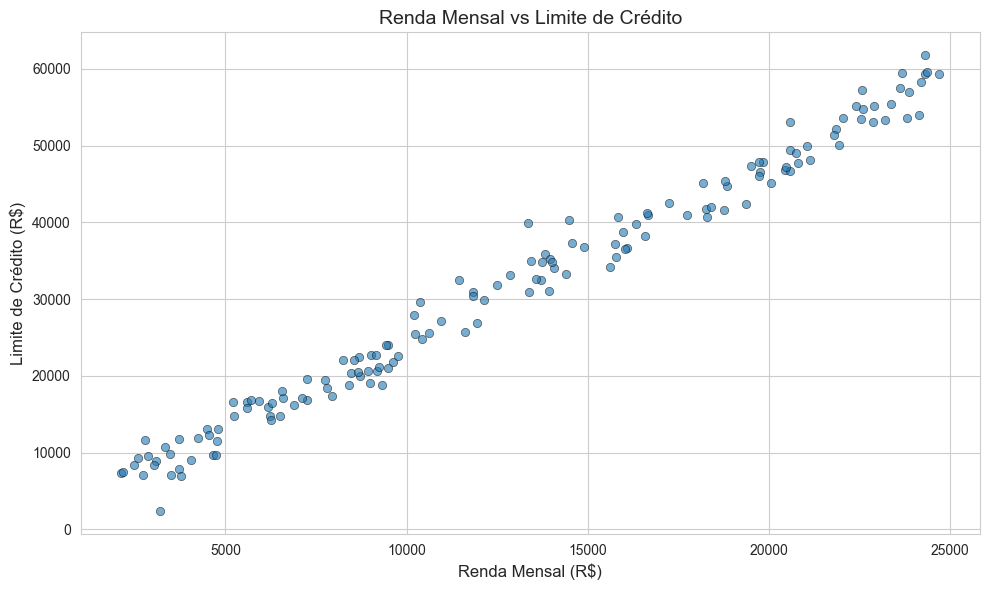

In [4]:
plt.figure(figsize=(10, 6))
plt.scatter(df['renda_mensal'], df['limite_credito'], alpha=0.6, edgecolors='k', linewidths=0.5)
plt.xlabel('Renda Mensal (R$)', fontsize=12)
plt.ylabel('Limite de Crédito (R$)', fontsize=12)
plt.title('Renda Mensal vs Limite de Crédito', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Correlação entre as Variáveis

In [5]:
correlacao = df['renda_mensal'].corr(df['limite_credito'])
print(f'Correlação de Pearson: {correlacao:.4f}')

Correlação de Pearson: 0.9916


## 5. Divisão dos Dados em Treino e Teste

Separamos 80% dos dados para treino e 20% para teste.

In [6]:
X = df[['renda_mensal']]
y = df['limite_credito']

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Dados de treino: {X_treino.shape[0]} amostras')
print(f'Dados de teste:  {X_teste.shape[0]} amostras')

Dados de treino: 120 amostras
Dados de teste:  30 amostras


## 6. Treinamento do Modelo

In [7]:
modelo = LinearRegression()
modelo.fit(X_treino, y_treino)

a = modelo.coef_[0]
b = modelo.intercept_

print(f'Coeficiente angular (a): {a:.4f}')
print(f'Intercepto (b): {b:.4f}')
print(f'\nEquação do modelo: limite = {a:.2f} × renda + {b:.2f}')

Coeficiente angular (a): 2.3249
Intercepto (b): 1380.2228

Equação do modelo: limite = 2.32 × renda + 1380.22


## 7. Interpretação dos Coeficientes

- **Coeficiente angular (a):** para cada R\$ 1,00 de aumento na renda mensal, o limite de crédito aprovado aumenta, em média, R\$ *a*.
- **Intercepto (b):** é o limite de crédito estimado quando a renda mensal é R\$ 0 (valor base teórico do modelo).

## 8. Previsões no Conjunto de Teste

In [8]:
y_pred = modelo.predict(X_teste)

comparacao = pd.DataFrame({
    'Renda Mensal': X_teste['renda_mensal'].values,
    'Limite Real': y_teste.values,
    'Limite Previsto': y_pred.round(2),
    'Erro': (y_teste.values - y_pred).round(2)
})
comparacao.head(10)

,Renda Mensal,Limite Real,Limite Previsto,Erro
0,20755.61,49092.25,49635.11,-542.86
1,11934.74,26825.28,29127.39,-2302.11
2,22528.86,53407.51,53757.75,-350.24
3,10244.71,25491.02,25198.23,292.79
4,19739.22,46007.17,47272.09,-1264.92
5,5922.05,16684.37,15148.44,1535.93
6,8461.49,20432.12,21052.41,-620.29
7,7790.99,18450.82,19493.56,-1042.74
8,3714.66,7901.94,10016.47,-2114.53
9,9610.65,21836.79,23724.10,-1887.31


## 9. Avaliação do Modelo

Vamos calcular as principais métricas para avaliar a qualidade do modelo.

In [10]:
r2 = r2_score(y_teste, y_pred)
mae = mean_absolute_error(y_teste, y_pred)
mse = mean_squared_error(y_teste, y_pred)
rmse = np.sqrt(mse)

print('╔══════════════════════════════════════╗')
print('║      MÉTRICAS DE AVALIAÇÃO           ║')
print('╠══════════════════════════════════════╣')
print(f'║  R² (coef. determinação): {r2:.4f}     ║')
print(f'║  MAE (erro médio abs.):   {mae:>10.2f} ║')
print(f'║  MSE (erro quadr. médio): {mse:>10.2f} ║')
print(f'║  RMSE (raiz do MSE):      {rmse:>10.2f} ║')
print('╚══════════════════════════════════════╝')

╔══════════════════════════════════════╗
║      MÉTRICAS DE AVALIAÇÃO           ║
╠══════════════════════════════════════╣
║  R² (coef. determinação): 0.9929     ║
║  MAE (erro médio abs.):      1176.08 ║
║  MSE (erro quadr. médio): 1899290.14 ║
║  RMSE (raiz do MSE):         1378.15 ║
╚══════════════════════════════════════╝


**Interpretação das métricas:**
- **R²**: varia de 0 a 1. Quanto mais próximo de 1, melhor o modelo explica a variabilidade dos dados.
- **MAE**: erro médio absoluto — em média, quanto o modelo erra em reais.
- **MSE**: erro quadrático médio — penaliza mais os erros grandes.
- **RMSE**: raiz do MSE — tem a mesma unidade da variável alvo (R$), facilitando a interpretação.

## 10. Visualização da Reta de Regressão

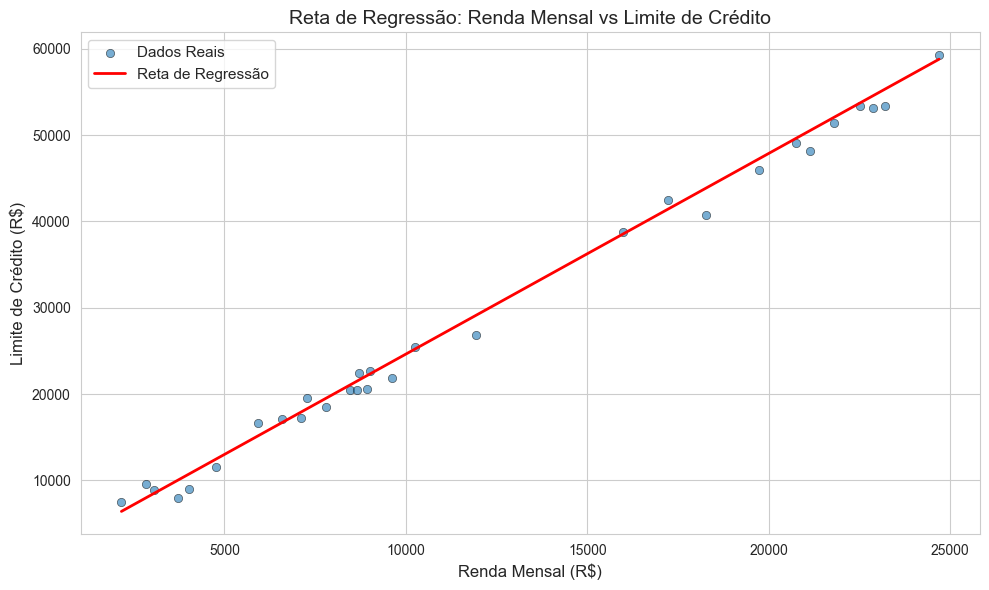

In [11]:
plt.figure(figsize=(10, 6))
plt.scatter(X_teste, y_teste, alpha=0.6, label='Dados Reais', edgecolors='k', linewidths=0.5)
plt.plot(X_teste.sort_values('renda_mensal'), 
         modelo.predict(X_teste.sort_values('renda_mensal')),
         color='red', linewidth=2, label='Reta de Regressão')
plt.xlabel('Renda Mensal (R$)', fontsize=12)
plt.ylabel('Limite de Crédito (R$)', fontsize=12)
plt.title('Reta de Regressão: Renda Mensal vs Limite de Crédito', fontsize=14)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 11. Análise de Resíduos

Os resíduos representam a diferença entre os valores reais e os previstos. Idealmente, devem estar distribuídos aleatoriamente ao redor de zero.

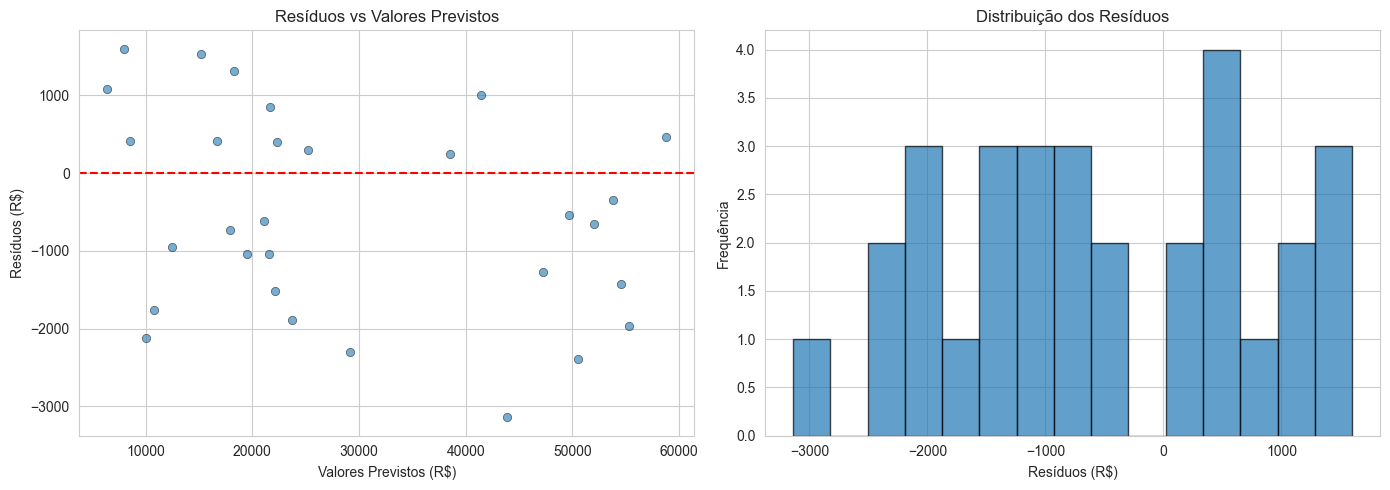

In [12]:
residuos = y_teste - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Resíduos vs Valores Previstos
axes[0].scatter(y_pred, residuos, alpha=0.6, edgecolors='k', linewidths=0.5)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Valores Previstos (R$)')
axes[0].set_ylabel('Resíduos (R$)')
axes[0].set_title('Resíduos vs Valores Previstos')

# Histograma dos Resíduos
axes[1].hist(residuos, bins=15, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Resíduos (R$)')
axes[1].set_ylabel('Frequência')
axes[1].set_title('Distribuição dos Resíduos')

plt.tight_layout()
plt.show()

## 12. Fazendo Novas Previsões

Com o modelo treinado, podemos prever o limite de crédito para novos clientes.

In [13]:
novas_rendas = pd.DataFrame({'renda_mensal': [3000, 5000, 8000, 12000, 20000]})
previsoes = modelo.predict(novas_rendas)

for renda, prev in zip(novas_rendas['renda_mensal'], previsoes):
    print(f'Renda: R$ {renda:>10,.2f}  →  Limite previsto: R$ {prev:>10,.2f}')

Renda: R$   3,000.00  →  Limite previsto: R$   8,354.95
Renda: R$   5,000.00  →  Limite previsto: R$  13,004.76
Renda: R$   8,000.00  →  Limite previsto: R$  19,979.49
Renda: R$  12,000.00  →  Limite previsto: R$  29,279.12
Renda: R$  20,000.00  →  Limite previsto: R$  47,878.38
